Dataset Shape: (873, 16)

First few rows:
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 873 entries, 0 to 872
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   match_id         873 non-null    int64
 1   competition      873 non-null    str  
 2   season           873 non-null    int64
 3   matchday         873 non-null    int64
 4   date             873 non-null    str  
 5   status           873 non-null    str  
 6   home_team_id     873 non-null    int64
 7   home_team_name   873 non-null    str  
 8   home_team_short  873 non-null    str  
 9   away_team_id     873 non-null    int64
 10  away_team_name   873 non-null    str  
 11  away_team_short  873 non-null    str  
 12  home_score       873 non-null    int64
 13  away_score       873 non-null    int64
 14  winner           873 non-null    str  
 15  duration         873 non-null    str  
dtypes: int64(7), str(9)
memory usage: 109.3 KB
None

Miss

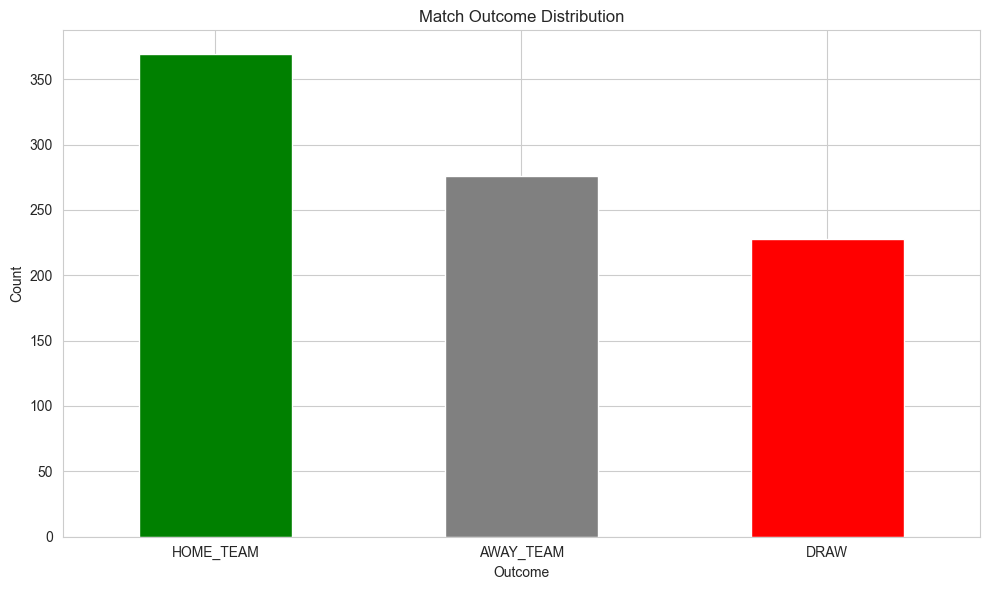

Home Goals - Mean: 1.5154639175257731
Away Goals - Mean: 1.2577319587628866


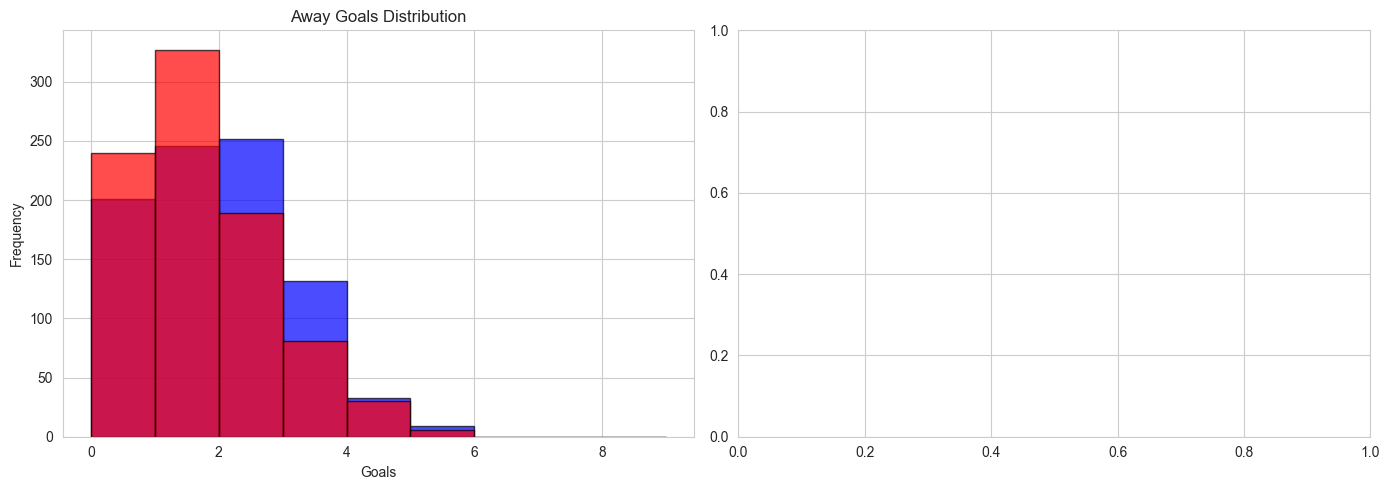

Home Win Rate: 42.3%
Draw Rate: 26.1%
Away Win Rate: 31.6%
Top 10 Teams by Total Wins
home_team_name
Arsenal FC              60.0
Manchester City FC      54.0
Aston Villa FC          45.0
Liverpool FC            42.0
Manchester United FC    42.0
Brentford FC            39.0
Chelsea FC              39.0
Everton FC              36.0
Fulham FC               36.0
Newcastle United FC     33.0
Name: count, dtype: float64


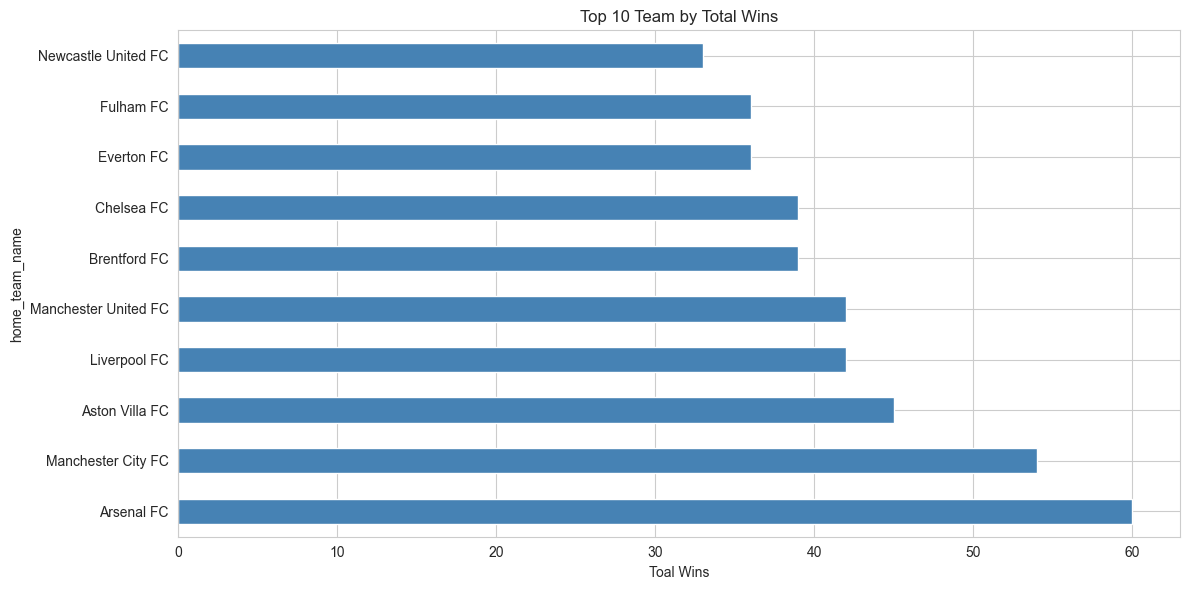

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../data/processed/premier_league_matches.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

# Basic info
print("Dataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

# Match distrubution
print("Match Outcomes:")
print(df['winner'].value_counts())
print("\nPercentages:")
print(df['winner'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(10, 6))
df["winner"].value_counts().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Match Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/outcome_distribution.png')
plt.show()

# Goal statistics
print("Home Goals - Mean:", df['home_score'].mean())
print("Away Goals - Mean:", df['away_score'].mean())

# Goal distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Home goals
axes[0].hist(df['home_score'], bins=range(0, 10), alpha=0.7, color='blue', edgecolor="black")
axes[0].set_title('Home Goals Distribution')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')

# Away goals
axes[0].hist(df['away_score'], bins=range(0, 10), alpha=0.7, color='red', edgecolor="black")
axes[0].set_title('Away Goals Distribution')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/goals_distribution.png')
plt.show()

# Calculate win percentages
total_matches = len(df)
home_wins = len(df[df['winner'] == 'HOME_TEAM'])
draws = len(df[df['winner'] == 'DRAW'])
away_wins = len(df[df['winner'] == 'AWAY_TEAM'])

print("Home Win Rate:", f"{(home_wins/total_matches)*100:.1f}%")
print("Draw Rate:", f"{(draws/total_matches)*100:.1f}%")
print("Away Win Rate:", f"{(away_wins/total_matches)*100:.1f}%")

# This shows there is some home advantage (importan for the model)

# Get most winning teams (home + away)
home_wins_by_team = df[df['winner'] == 'HOME_TEAM']['home_team_name'].value_counts()
away_wins_by_team = df[df['winner'] == 'AWAY_TEAM']['away_team_name'].value_counts()

total_wins = home_wins_by_team.add(away_wins_by_team, fill_value=0).sort_values(ascending=False)

print("Top 10 Teams by Total Wins")
print(total_wins.head(10))

# Visualize
plt.figure(figsize=(12, 6))
total_wins.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Team by Total Wins')
plt.xlabel('Toal Wins')
plt.tight_layout()
plt.savefig('../data/top_teams.png')
plt.show()